In [1]:
import pandas as pd
import os

# Визначаємо шляхи до папок
# Шлях до ваших сирих даних (змініть на свій, якщо він інший)
DATA_PATH = "C:/University/6 grade/Diploma/AniDB 2020/"
processed_data_path = os.path.join('..', 'data', 'processed')

# 1. Завантажуємо очищені дані про аніме (наш фундамент)
df_anime = pd.read_parquet(os.path.join(processed_data_path, 'anime_clean.parquet'))

# 2. Завантажуємо описи статусів перегляду
df_status = pd.read_csv(os.path.join(DATA_PATH, 'watching_status.csv'))

print(f"Завантажено аніме: {df_anime.shape[0]} рядків")
print("Доступні статуси:")
print(df_status)

Завантажено аніме: 17562 рядків
Доступні статуси:
   status         description
0       1  Currently Watching
1       2           Completed
2       3             On Hold
3       4             Dropped
4       6       Plan to Watch


In [2]:
# Визначаємо типи даних для кожної колонки, щоб зекономити RAM
# int32 достатньо для мільйонів ID, int8 - для маленьких оцінок (0-10)
dtypes = {
    'user_id': 'int32',
    'anime_id': 'int32',
    'rating': 'int8',
    'watching_status': 'int8',
    'watched_episodes': 'int32'
}

print("Починаю завантаження animelist.csv (це може зайняти час)...")

# Завантажуємо файл
df_user_list = pd.read_csv(
    os.path.join(DATA_PATH, 'animelist.csv'),
    dtype=dtypes
)

print(f"Успішно завантажено! Кількість оцінок: {len(df_user_list):,}")

Починаю завантаження animelist.csv (це може зайняти час)...
Успішно завантажено! Кількість оцінок: 109,224,747


In [3]:
# У цьому датасеті рейтинг '0' означає, що користувач не поставив оцінку
zero_ratings = (df_user_list['rating'] == 0).sum()
zero_pct = (zero_ratings / len(df_user_list)) * 100

print(f"Кількість записів без оцінки (0): {zero_ratings:,} ({zero_pct:.2f}%)")

# Перевіримо перші рядки
print("\nПриклад даних користувачів:")
print(df_user_list.head())

Кількість записів без оцінки (0): 46,827,035 (42.87%)

Приклад даних користувачів:
   user_id  anime_id  rating  watching_status  watched_episodes
0        0        67       9                1                 1
1        0      6702       7                1                 4
2        0       242      10                1                 4
3        0      4898       0                1                 1
4        0        21      10                1                 0


In [5]:
# Отримуємо набір (set) унікальних ID з очищеного файлу аніме
# Використання set значно прискорює пошук порівняно зі списком
valid_anime_ids = set(df_anime['MAL_ID'].unique())

# Рахуємо кількість записів до видалення
initial_count = len(df_user_list)
mask = df_user_list['anime_id'].isin(valid_anime_ids)

# Оновлюємо датафрейм, залишаючи лише валідні ID
df_user_list = df_user_list[mask].reset_index(drop=True)

final_count = len(df_user_list)
removed_count = initial_count - final_count

print(f"--- РЕЗУЛЬТАТ СИНХРОНІЗАЦІЇ ---")
print(f"Видалено записів про аніме, яких немає в базі: {removed_count:,}")
print(f"Залишилося записів у animelist: {final_count:,}")

--- РЕЗУЛЬТАТ СИНХРОНІЗАЦІЇ ---
Видалено записів про аніме, яких немає в базі: 0
Залишилося записів у animelist: 109,224,747


C:\Users\Anton\AppData\Local\Temp\ipykernel_2500\830378175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts_all.index, y=rating_counts_all.values, ax=ax1, palette="viridis")
C:\Users\Anton\AppData\Local\Temp\ipykernel_2500\830378175.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts_nonzero.index, y=rating_counts_nonzero.values, ax=ax2, palette="magma")


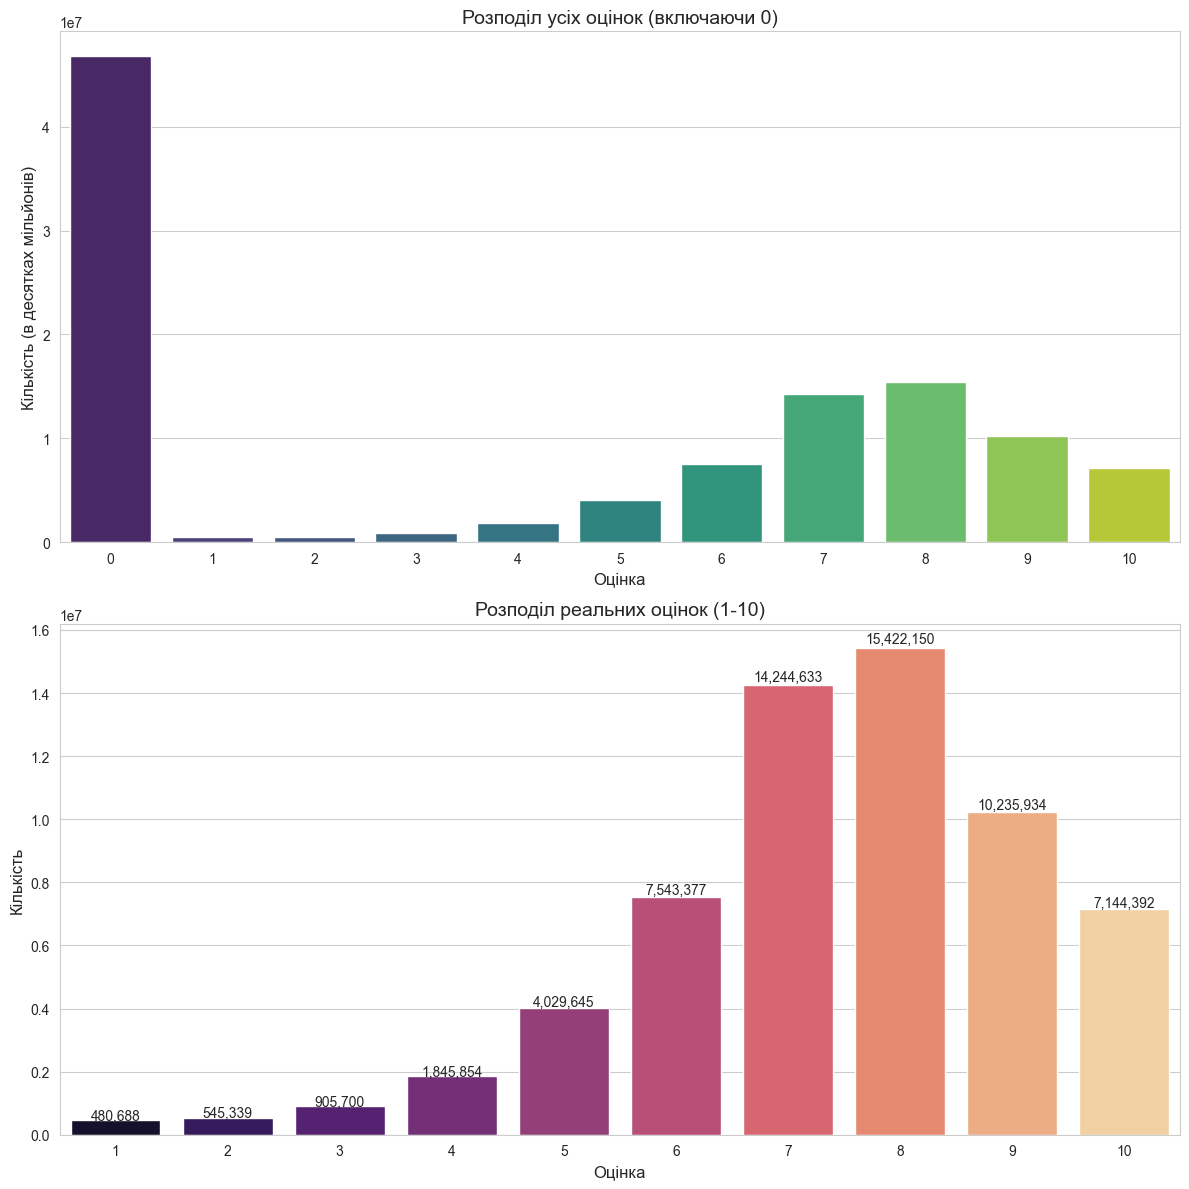

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- ГРАФІК 1: Всі оцінки (0-10) ---
rating_counts_all = df_user_list['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts_all.index, y=rating_counts_all.values, ax=ax1, palette="viridis")
ax1.set_title('Розподіл усіх оцінок (включаючи 0)', fontsize=14)
ax1.set_xlabel('Оцінка', fontsize=12)
ax1.set_ylabel('Кількість (в десятках мільйонів)', fontsize=12)

# --- ГРАФІК 2: Оцінки без нуля (1-10) ---
df_nonzero = df_user_list[df_user_list['rating'] > 0]
rating_counts_nonzero = df_nonzero['rating'].value_counts().sort_index()

sns.barplot(x=rating_counts_nonzero.index, y=rating_counts_nonzero.values, ax=ax2, palette="magma")
ax2.set_title('Розподіл реальних оцінок (1-10)', fontsize=14)
ax2.set_xlabel('Оцінка', fontsize=12)
ax2.set_ylabel('Кількість', fontsize=12)

# Додаємо підписи значень над стовпчиками для другого графіка
for i, v in enumerate(rating_counts_nonzero.values):
    ax2.text(i, v + (v * 0.01), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
df_user_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 109224747 entries, 0 to 109224746
Data columns (total 5 columns):
 #   Column            Dtype
---  ------            -----
 0   user_id           int32
 1   anime_id          int32
 2   rating            int8 
 3   watching_status   int8 
 4   watched_episodes  int32
dtypes: int32(3), int8(2)
memory usage: 1.4 GB


In [9]:
# Перевірка максимальних значень у кожному стовпчику
print("--- ФАКТИЧНІ МАКСИМАЛЬНІ ЗНАЧЕННЯ ---")
max_values = df_user_list.max()

for col, val in max_values.items():
    dtype = df_user_list[col].dtype
    print(f"Колонка '{col}':")
    print(f"  - Максимум у даних: {val:,}")
    print(f"  - Використаний тип: {dtype}")
    
    # Додаткова перевірка для наочності
    if dtype == 'int8' and val <= 127:
        print("  - Статус: OK (вміщується в int8)")
    elif dtype == 'int32' and val <= 2147483647:
        print("  - Статус: OK (вміщується в int32)")

--- ФАКТИЧНІ МАКСИМАЛЬНІ ЗНАЧЕННЯ ---
Колонка 'user_id':
  - Максимум у даних: 353,404
  - Використаний тип: int32
  - Статус: OK (вміщується в int32)
Колонка 'anime_id':
  - Максимум у даних: 48,492
  - Використаний тип: int32
  - Статус: OK (вміщується в int32)
Колонка 'rating':
  - Максимум у даних: 10
  - Використаний тип: int8
  - Статус: OK (вміщується в int8)
Колонка 'watching_status':
  - Максимум у даних: 55
  - Використаний тип: int8
  - Статус: OK (вміщується в int8)
Колонка 'watched_episodes':
  - Максимум у даних: 65,535
  - Використаний тип: int32
  - Статус: OK (вміщується в int32)


In [10]:
# 1. Оптимізація колонок, де значення вміщуються в 2 байти (uint16)
# Ми використовуємо uint16, оскільки у нас немає від'ємних значень
optimization_dict = {
    'anime_id': 'uint16',
    'watched_episodes': 'uint16'
}

print("Починаю перетворення типів...")

try:
    # Застосовуємо нові типи даних
    df_user_list = df_user_list.astype(optimization_dict)
    
    print("--- УСПІХ ---")
    print("Типи даних оптимізовано.")
    
    # Виводимо інформацію про нову структуру пам'яті
    print("\nНові типи колонок:")
    print(df_user_list.dtypes)
    
    # Порівняння пам'яті
    memory_usage = df_user_list.memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"\nПоточне використання оперативної пам'яті: {memory_usage:.2f} MB")

except Exception as e:
    print(f"--- ПОМИЛКА ---")
    print(f"Під час перетворення виникла проблема: {e}")

Починаю перетворення типів...
--- УСПІХ ---
Типи даних оптимізовано.

Нові типи колонок:
user_id              int32
anime_id            uint16
rating                int8
watching_status       int8
watched_episodes    uint16
dtype: object

Поточне використання оперативної пам'яті: 1041.65 MB


In [14]:
df_status.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   status        5 non-null      int64
 1    description  5 non-null      str  
dtypes: int64(1), str(1)
memory usage: 266.0 bytes


In [23]:
# Видаляємо зайві пробіли з усіх назв колонок
df_status.columns = df_status.columns.str.strip()

In [24]:
# 1. Отримуємо розподіл усіх значень у колонці watching_status
status_distribution = df_user_list['watching_status'].value_counts().sort_index().reset_index()
status_distribution.columns = ['status', 'count']

# 2. Об'єднуємо з описом статусів (df_status), щоб побачити офіційні назви
# Використовуємо left join, щоб зберегти аномальні ID, для яких немає опису
status_analysis = pd.merge(status_distribution, df_status, on='status', how='left')

# Замінюємо порожні описи для аномалій на "ANOMALY"
status_analysis['description'] = status_analysis['description'].fillna('!!! ANOMALY !!!')

print("--- РОЗПОДІЛ СТАТУСІВ ТА АНОМАЛІЇ ---")
print(status_analysis.to_string(index=False))

# 3. Підрахунок загальної кількості аномалій
# Очікувані статуси зазвичай: 1, 2, 3, 4, 6
expected_statuses = df_status['status'].unique()
anomalies_mask = ~df_user_list['watching_status'].isin(expected_statuses)
anomaly_count = anomalies_mask.sum()
anomaly_pct = (anomaly_count / len(df_user_list)) * 100

print(f"\n--- ПІДСУМОК ---")
print(f"Загальна кількість аномальних записів: {anomaly_count:,}")
print(f"Відсоток аномалій у датасеті: {anomaly_pct:.4f}%")

# Виведемо приклад рядків з аномаліями, якщо вони є
if anomaly_count > 0:
    print("\nПриклад записів з аномальним статусом:")
    print(df_user_list[anomalies_mask].head())

--- РОЗПОДІЛ СТАТУСІВ ТА АНОМАЛІЇ ---
 status    count        description
      0      531    !!! ANOMALY !!!
      1  5228658 Currently Watching
      2 68089751          Completed
      3  3700514            On Hold
      4  4266591            Dropped
      5        6    !!! ANOMALY !!!
      6 27938693      Plan to Watch
     33        2    !!! ANOMALY !!!
     55        1    !!! ANOMALY !!!

--- ПІДСУМОК ---
Загальна кількість аномальних записів: 540
Відсоток аномалій у датасеті: 0.0005%

Приклад записів з аномальним статусом:
         user_id  anime_id  rating  watching_status  watched_episodes
2970875    10015      6682       0                0                 0
2970876    10015     18893       0                0                 0
2970877    10015      4999       0                0                 0
2970878    10015      7817       0                0                 0
2970879    10015      6347       0                0                 0


In [25]:
# 1. Створюємо список дозволених статусів на основі допоміжного файлу
valid_status_ids = df_status['status'].unique()

# 2. Фільтруємо основний датафрейм
# Залишаємо лише ті рядки, де статус входить у список валідних
initial_rows = len(df_user_list)
df_user_list = df_user_list[df_user_list['watching_status'].isin(valid_status_ids)].reset_index(drop=True)

# 3. Підрахунок результатів
final_rows = len(df_user_list)
print(f"--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---")
print(f"Видалено аномальних рядків: {initial_rows - final_rows}")
print(f"Поточна кількість записів: {final_rows:,}")

--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---
Видалено аномальних рядків: 540
Поточна кількість записів: 109,224,207


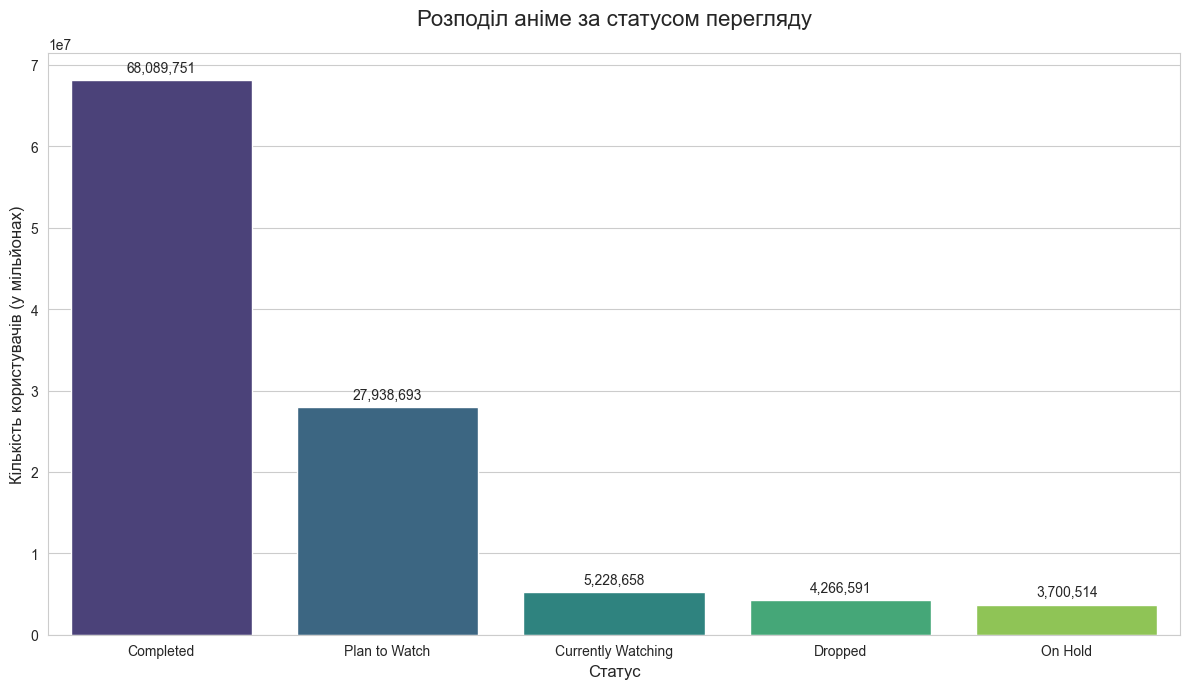

In [26]:
# 1. Підрахунок кількості кожного статусу
status_counts = df_user_list['watching_status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']

# 2. Додавання текстових описів із df_status
status_viz_data = pd.merge(status_counts, df_status, on='status')

# 3. Побудова графіка
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Створюємо графік
plot = sns.barplot(
    data=status_viz_data, 
    x='description', 
    y='count', 
    palette='viridis',
    hue='description',
    legend=False
)

# Налаштування заголовків
plt.title('Розподіл аніме за статусом перегляду', fontsize=16, pad=20)
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Кількість користувачів (у мільйонах)', fontsize=12)

# Додавання точних значень над стовпчиками
for p in plot.patches:
    plot.annotate(f'{p.get_height():,.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
# 1. Аналіз статусів 'Completed' (ID = 2) без оцінки (Rating = 0)
completed_mask = df_user_list['watching_status'] == 2
zero_rating_mask = df_user_list['rating'] == 0

completed_zero_rating = df_user_list[completed_mask & zero_rating_mask]
total_completed = completed_mask.sum()

# 2. Аналіз інших статусів (ID != 2) з наявною оцінкою (Rating > 0)
others_mask = df_user_list['watching_status'] != 2
has_rating_mask = df_user_list['rating'] > 0

others_with_rating = df_user_list[others_mask & has_rating_mask]
total_others = others_mask.sum()

# 3. Виведення результатів
print("--- АНАЛІЗ ВЗАЄМОЗВ'ЯЗКУ СТАТУСУ ТА ОЦІНКИ ---")

print(f"\nСтатус 'Completed':")
print(f"  - Всього завершених аніме: {total_completed:,}")
print(f"  - Завершено БЕЗ оцінки (0): {len(completed_zero_rating):,}")
print(f"  - Частка без оцінок: {(len(completed_zero_rating) / total_completed * 100):.2f}%")

print(f"\nІнші статуси (Watching, Dropped, Plan to Watch тощо):")
print(f"  - Всього записів в інших статусах: {total_others:,}")
print(f"  - З виставленою оцінкою (1-10): {len(others_with_rating):,}")
print(f"  - Частка з оцінками: {(len(others_with_rating) / total_others * 100):.2f}%")    

--- АНАЛІЗ ВЗАЄМОЗВ'ЯЗКУ СТАТУСУ ТА ОЦІНКИ ---

Статус 'Completed':
  - Всього завершених аніме: 68,089,751
  - Завершено БЕЗ оцінки (0): 10,456,473
  - Частка без оцінок: 15.36%

Інші статуси (Watching, Dropped, Plan to Watch тощо):
  - Всього записів в інших статусах: 41,134,456
  - З виставленою оцінкою (1-10): 4,764,355
  - Частка з оцінками: 11.58%


In [29]:
# Налаштування шляхів
processed_path = os.path.join('..', 'data', 'processed')
os.makedirs(processed_path, exist_ok=True)

def save_parquet(df, filename):
    full_path = os.path.join(processed_path, filename)
    df.to_parquet(full_path, engine='pyarrow', index=False)
    print(f"Збережено: {filename} ({len(df):,} рядків)")

# --- ЧАСТИНА 1: ЗАГАЛЬНІ ФАЙЛИ ---

print("Збереження загальних файлів...")

# 1. Всі дані
save_parquet(df_user_list, 'user_list_full.parquet')

# 2. Тільки з оцінками (rating > 0)
df_rated = df_user_list[df_user_list['rating'] > 0]
save_parquet(df_rated, 'user_list_rated.parquet')

# 3. Тільки завершені та з оцінками (rating > 0 & watching_status = 2)
# Лише 3 колонки: user_id, anime_id, rating
df_completed_rated = df_user_list[
    (df_user_list['rating'] > 0) & (df_user_list['watching_status'] == 2)
][['user_id', 'anime_id', 'rating']]
save_parquet(df_completed_rated, 'user_list_completed_rated.parquet')


# --- ЧАСТИНА 2: БЕЗПЕЧНІ ФАЙЛИ (SAFE) ---

print("\nЗбереження безпечних (Safe) файлів...")

# Завантажуємо список безпечних аніме
df_anime_safe = pd.read_parquet(os.path.join(processed_path, 'anime_safe.parquet'))
safe_ids = set(df_anime_safe['MAL_ID'].unique())

# Фільтруємо основний датафрейм за безпечними ID
df_user_safe_base = df_user_list[df_user_list['anime_id'].isin(safe_ids)]

# 4. Безпечні всі дані
save_parquet(df_user_safe_base, 'user_list_safe_full.parquet')

# 5. Безпечні тільки з оцінками
df_safe_rated = df_user_safe_base[df_user_safe_base['rating'] > 0]
save_parquet(df_safe_rated, 'user_list_safe_rated.parquet')

# 6. Безпечні завершені з оцінками (3 колонки)
df_safe_completed_rated = df_user_safe_base[
    (df_user_safe_base['rating'] > 0) & (df_user_safe_base['watching_status'] == 2)
][['user_id', 'anime_id', 'rating']]
save_parquet(df_safe_completed_rated, 'user_list_safe_completed_rated.parquet')

print("\n--- ВСІ ФАЙЛИ УСПІШНО СТВОРЕНО ---")

Збереження загальних файлів...
Збережено: user_list_full.parquet (109,224,207 рядків)
Збережено: user_list_rated.parquet (62,397,633 рядків)
Збережено: user_list_completed_rated.parquet (57,633,278 рядків)

Збереження безпечних (Safe) файлів...
Збережено: user_list_safe_full.parquet (107,124,006 рядків)
Збережено: user_list_safe_rated.parquet (61,303,790 рядків)
Збережено: user_list_safe_completed_rated.parquet (56,628,402 рядків)

--- ВСІ ФАЙЛИ УСПІШНО СТВОРЕНО ---
